# V. Prediction Models
This notebook aims to predict future high-impact papers. We build and evaluate multiple models, from simple baselines to a deep neural network, to classify whether a paper will rank in the top 10% of citations for its publication year.

## 1. Imports and Initial Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim


ModuleNotFoundError: No module named 'torch'

## 2. isTop10Percent Target Variable
The target variable is `isTop10Percent`. To create this, we group the data by publication year and calculate the 90th percentile citation count for that year. Any paper meeting or exceeding this threshold is labeled `1`, otherwise it is labeled `0`.

In [ ]:
# Loads dataset and creates binary classification target
# @param filePath - Path to processed parquet file
# @returns - DataFrame with binary target
def preparePredictionData(filePath):
    analyticalData = pd.read_parquet(filePath)
    # Calculate 90th percentile threshold within each year group
    thresholds = analyticalData.groupby("year")["n_citation"].transform(lambda group: group.quantile(0.9))
    analyticalData["isTop10Percent"] = (analyticalData["n_citation"] >= thresholds).astype(int)
    analyticalData["authorCount"] = analyticalData["authors"].apply(lambda authorList: len(authorList) if authorList is not None else 0)
    analyticalData["referenceCount"] = analyticalData["references"].apply(lambda refList: len(refList) if refList is not None else 0)
    return analyticalData

predictionData = preparePredictionData("../../data/processed_dblp.parquet")


## 3. meanAuthorDegree
We calculate `meanAuthorDegree` from a co-authorship graph. This metric captures the average connectivity of a paper's authors, acting as a proxy for their influence or embeddedness in the research community.

In [ ]:
# Computes mean author degree from co-authorship graph
# @param dataFrame - Dataset containing authors
# @returns - Array of mean degrees
def computeGraphMetrics(dataFrame):
    coauthorGraph = nx.Graph()
    # Build graph from author lists
    for authors in dataFrame["authors"]:
        if authors is None:
            continue
        validAuthors =[author for author in authors if author is not None]
        authorCount = len(validAuthors)
        for i in range(authorCount):
            coauthorGraph.add_node(validAuthors[i])
            for j in range(i + 1, authorCount):
                coauthorGraph.add_edge(validAuthors[i], validAuthors[j])
    degreeDict = dict(coauthorGraph.degree())
    
    # Map author degrees back to each paper
    def getMeanDegree(authorsList):
        if authorsList is None:
            return 0.0
        validAuthors = [author for author in authorsList if author is not None]
        if len(validAuthors) == 0:
            return 0.0
        degrees =[degreeDict.get(author, 0) for author in validAuthors]
        return sum(degrees) / len(validAuthors)
        
    return dataFrame["authors"].apply(getMeanDegree)

predictionData["meanAuthorDegree"] = computeGraphMetrics(predictionData)

# Chronological data split
splitYear = 2012
trainData = predictionData[predictionData["year"] < splitYear].copy()
testData = predictionData[predictionData["year"] >= splitYear].copy()

# Isolate features and target
columnsToDrop =["id", "venue", "year", "n_citation", "authors", "references", "isTop10Percent"]
featureColumns =[col for col in trainData.columns if col not in columnsToDrop]

trainFeaturesRaw = trainData[featureColumns]
trainTarget = trainData["isTop10Percent"]
testFeaturesRaw = testData[featureColumns]
testTarget = testData["isTop10Percent"]

# Scale features
scaler = StandardScaler()
trainFeatures = pd.DataFrame(scaler.fit_transform(trainFeaturesRaw), columns=featureColumns)
testFeatures = pd.DataFrame(scaler.transform(testFeaturesRaw), columns=featureColumns)


## 4. Baseline and Ensemble Model Evaluation
We evaluate several standard classifiers. Due to the severe class imbalance (~10% positive class), most models use `class_weight` parameters to penalize misclassification of the minority class. The key evaluation metric is the Area Under the Precision-Recall Curve (AUPRC), which is more informative than ROC AUC for imbalanced tasks.

In [ ]:
# Evaluates classifier performance
# @param trueLabels - Ground truth array
# @param predictedLabels - Binary predictions array
# @param predictedProbabilities - Probability scores array
# @returns - Dictionary of metrics
def evaluatePerformance(trueLabels, predictedLabels, predictedProbabilities):
    return {
        "precision": precision_score(trueLabels, predictedLabels, zero_division=0),
        "recall": recall_score(trueLabels, predictedLabels, zero_division=0),
        "f1": f1_score(trueLabels, predictedLabels, zero_division=0),
        "auprc": average_precision_score(trueLabels, predictedProbabilities)
    }

models = {
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=64),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", max_depth=10, random_state=64),
    "LightGBM": LGBMClassifier(class_weight="balanced", random_state=64)
}

results = {}
modelProbabilities = {}
modelPredictions = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(trainFeatures, trainTarget)
    predictions = model.predict(testFeatures)
    # Get probabilities for AUPRC calculation
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(testFeatures)[:, 1]
    else:
        probabilities = predictions # For models that dont output probabilities
    
    modelProbabilities[name] = probabilities
    modelPredictions[name] = predictions
    results[name] = evaluatePerformance(testTarget, predictions, probabilities)

resultsDataFrame = pd.DataFrame(results).T
print("Model comparison:")
print(resultsDataFrame)


[LightGBM] [Info] Number of positive: 16983, number of negative: 151289
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009929 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13136
[LightGBM] [Info] Number of data points in the train set: 168272, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Model Performance Metrics:
               precision    recall        f1     auprc
Decision Tree   0.194487  0.371837  0.255392  0.137087
KNN             0.418293  0.109883  0.174046  0.192030
Naive Bayes     0.230609  0.705902  0.347647  0.511726
Random Forest   0.154710  0.925224  0.265093  0.314386
LightGBM        0.151000  0.929134  0.259782  0.514994


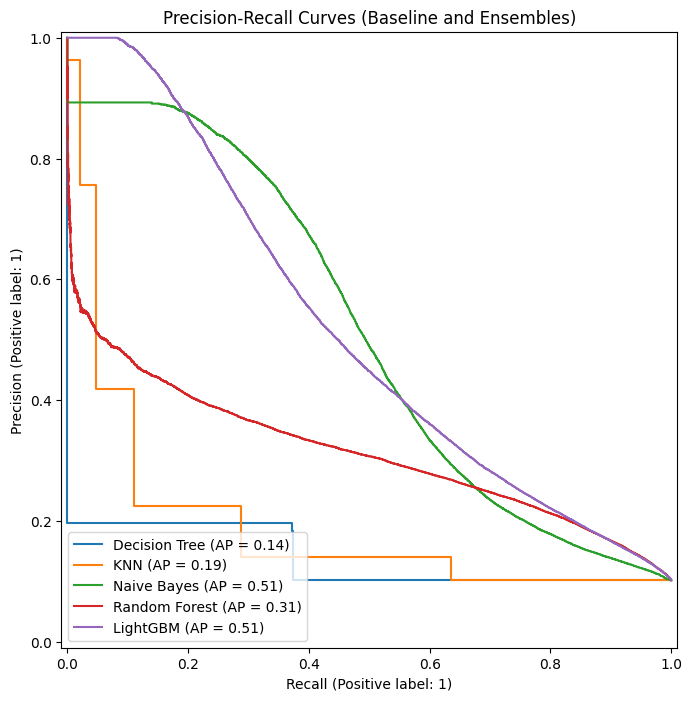

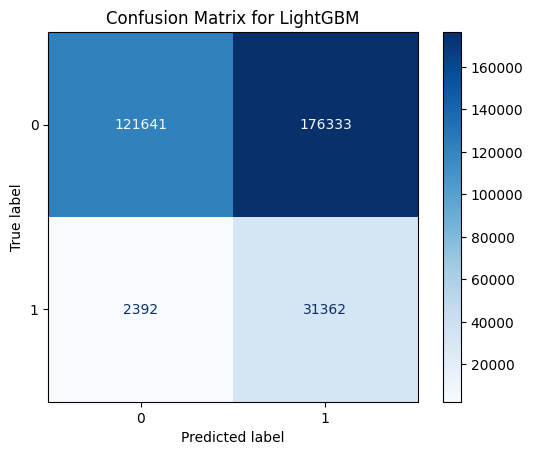

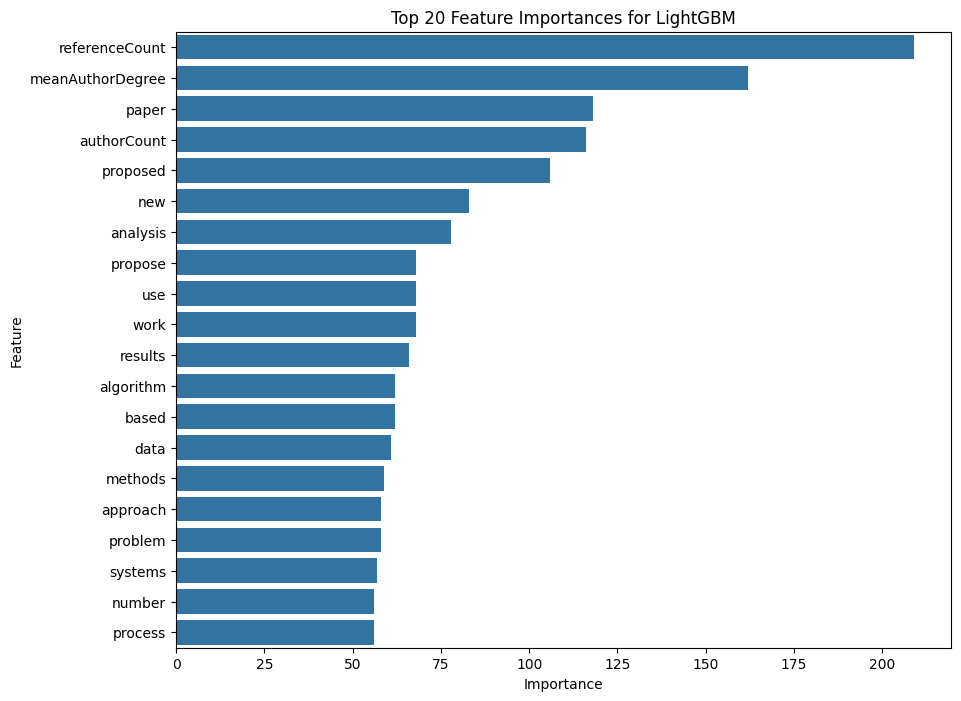

In [ ]:
# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))
for name, probabilities in modelProbabilities.items():
    PrecisionRecallDisplay.from_predictions(testTarget, probabilities, name=name, ax=plt.gca())
plt.title("Precision-Recall Curves (Baseline and Ensemble Models)")
plt.show()

# Plot confusion matrix for best model
lgbmPredictions = modelPredictions["LightGBM"]
confMatrix = confusion_matrix(testTarget, lgbmPredictions)
disp = ConfusionMatrixDisplay(confusion_matrix=confMatrix)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for LightGBM")
plt.show()

# Plot feature importances for best model
featureImportances = pd.Series(models["LightGBM"].feature_importances_, index=featureColumns)
topFeatures = featureImportances.nlargest(20)
plt.figure(figsize=(10, 8))
sns.barplot(x=topFeatures, y=topFeatures.index)
plt.title("Top 20 Feature Importances for LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Isolate structural vs textual features
top_features = pd.Series(models["LightGBM"].feature_importances_, index=featureColumns).sort_values(ascending=False)

structural_feats =["referenceCount", "meanAuthorDegree", "authorCount"]
top_text_feats =[f for f in top_features.index if f not in structural_feats][:5]

print("Structural feature importances:")
for feat in structural_feats:
    print(f"{feat}: {top_features[feat]}")

print("\nTop text features:")
for feat in top_text_feats:
    print(f"{feat}: {top_features[feat]}")

## 5. Deep Learning Model Definition
We implement a Multilayer Perceptron (MLP) using PyTorch. We have 3 hidden layers with decreasing numbers of neurons (256, 128, 64). Each layer uses a ReLU activation function, Batch Normalization to stabilize training, and Dropout for regularization.

In [ ]:
# Defines MLP architecture
class ImpactPredictorMLP(nn.Module):
    # Defines layers
    def __init__(self, inputSize):
        super().__init__()
        self.layerOne = nn.Linear(inputSize, 256)
        self.bnOne = nn.BatchNorm1d(256)
        self.activationOne = nn.ReLU()
        self.dropoutOne = nn.Dropout(0.2)
        
        self.layerTwo = nn.Linear(256, 128)
        self.bnTwo = nn.BatchNorm1d(128)
        self.activationTwo = nn.ReLU()
        self.dropoutTwo = nn.Dropout(0.2)
        
        self.layerThree = nn.Linear(128, 64)
        self.bnThree = nn.BatchNorm1d(64)
        self.activationThree = nn.ReLU()
        self.dropoutThree = nn.Dropout(0.2)
        
        self.outputLayer = nn.Linear(64, 1)
        
    # Defines forward pass logic
    def forward(self, inputData):
        hiddenOne = self.dropoutOne(self.activationOne(self.bnOne(self.layerOne(inputData))))
        hiddenTwo = self.dropoutTwo(self.activationTwo(self.bnTwo(self.layerTwo(hiddenOne))))
        hiddenThree = self.dropoutThree(self.activationThree(self.bnThree(self.layerThree(hiddenTwo))))
        return self.outputLayer(hiddenThree)

# Convert data to PyTorch Tensors
tensorTrainFeatures = torch.tensor(trainFeatures.values, dtype=torch.float32)
tensorTrainTarget = torch.tensor(trainTarget.values, dtype=torch.float32).unsqueeze(1)
tensorTestFeatures = torch.tensor(testFeatures.values, dtype=torch.float32)
tensorTestTarget = torch.tensor(testTarget.values, dtype=torch.float32).unsqueeze(1)


## 6. Deep Learning Model Training and Evaluation
The MLP is trained for 500 epochs using the Adam optimizer. To handle the class imbalance, we use `BCEWithLogitsLoss` and supply a `pos_weight` argument. This weight is the ratio of negative to positive samples, which heavily penalizes the model for misclassifying the rare positive class. After training, we evaluate its performance on the test set and plot its PRC curve.

Epoch 50/500 Loss: 1.1129
Epoch 100/500 Loss: 1.0897
Epoch 150/500 Loss: 1.0670
Epoch 200/500 Loss: 1.0445
Epoch 250/500 Loss: 1.0237
Epoch 300/500 Loss: 1.0015
Epoch 350/500 Loss: 0.9813
Epoch 400/500 Loss: 0.9644
Epoch 450/500 Loss: 0.9466
Epoch 500/500 Loss: 0.9305

Deep learning (MLP) results:
precision: 0.1497
recall: 0.9075
f1: 0.2571
auprc: 0.4709


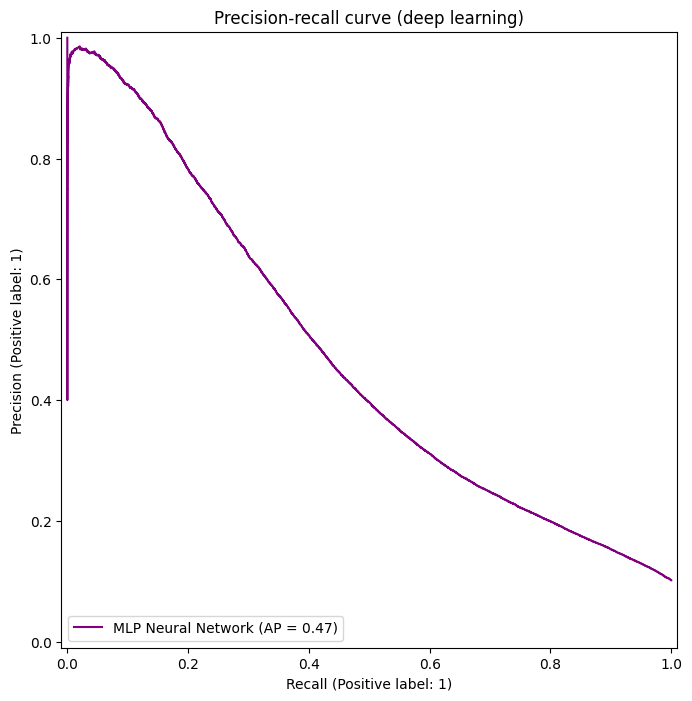

In [ ]:
inputDimension = trainFeatures.shape[1]
deepModel = ImpactPredictorMLP(inputDimension)

# Calculate weight to handle class imbalance
numNegative = (trainTarget == 0).sum()
numPositive = (trainTarget == 1).sum()
positiveWeight = torch.tensor([numNegative / numPositive], dtype=torch.float32)
lossFunction = nn.BCEWithLogitsLoss(pos_weight=positiveWeight)
optimizer = optim.Adam(deepModel.parameters(), lr=0.001)
epochCount = 500

deepModel.train() # Set model to training mode
for epoch in range(epochCount):
    # Executes forward pass
    rawPredictions = deepModel(tensorTrainFeatures)
    
    # Calculates loss function
    loss = lossFunction(rawPredictions, tensorTrainTarget)
    
    # Executes backpropagation
    optimizer.zero_grad() # Clear previous gradients
    loss.backward() # Compute new gradients
    optimizer.step() # Update model weights
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{epochCount} Loss: {loss.item():.4f}")

deepModel.eval() # Set model to evaluation mode
with torch.no_grad(): # Disable gradient calculation for inference
    testLogits = deepModel(tensorTestFeatures)
    testProbabilities = torch.sigmoid(testLogits).squeeze().numpy()
    testPredictions = (testProbabilities >= 0.5).astype(int)

deepLearningMetrics = evaluatePerformance(testTarget.values, testPredictions, testProbabilities)
print("\nDeep learning (MLP) results:")
for metricName, metricValue in deepLearningMetrics.items():
    print(f"{metricName}: {metricValue:.4f}")

# Plot PRC curve for MLP
plt.figure(figsize=(10, 8))
PrecisionRecallDisplay.from_predictions(testTarget.values, testProbabilities, name="MLP Neural Network", ax=plt.gca(), color="purple")
plt.title("Precision-recall curve (deep learning)")
plt.show()
